# Recalculo de pendientes (Newton)

Este notebook recalcula la pendiente `k` de las rectas `y = ±k x` usando
una estimacion numerica de la probabilidad `g` (proporcion de puntos que
convergen a la raiz `z = -1` dentro de un disco de radio `R`).

Formula usada: `k = tan(pi * g)`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def newton_step_z_minus_1_power_m_z_plus_1(z, m):
    """Newton para p(z) = (z-1)^m (z+1)."""
    z = np.asarray(z, dtype=np.complex128)
    pz = (z - 1) ** m * (z + 1)
    dp = (z - 1) ** (m - 1) * ((m + 1) * z + (m - 1))
    update = np.zeros_like(z)
    np.divide(pz, dp, out=update, where=dp != 0)
    return z - update


def compute_root_ids(m, x_range, y_range, points, max_iter, tol=1e-6):
    xs = np.linspace(x_range[0], x_range[1], points)
    ys = np.linspace(y_range[1], y_range[0], points)
    grid = xs[None, :] + 1j * ys[:, None]
    current = grid.copy()
    root_ids = np.zeros(grid.shape, dtype=int)

    for _ in range(max_iter):
        active = root_ids == 0
        if not np.any(active):
            break
        updated = newton_step_z_minus_1_power_m_z_plus_1(current[active], m)
        current[active] = updated

        new_ids = np.zeros_like(updated, dtype=int)
        new_ids[np.abs(updated + 1) < tol] = 1  # z = -1
        new_ids[np.abs(updated - 1) < tol] = 2  # z = +1

        if np.any(new_ids):
            stored = root_ids[active]
            mask = new_ids > 0
            stored[mask] = new_ids[mask]
            root_ids[active] = stored

    return xs, ys, root_ids


def estimate_k_from_root_ids(xs, ys, root_ids, R, use_converged_only=True):
    X, Y = np.meshgrid(xs, ys)
    disk = (X ** 2 + Y ** 2) <= (R ** 2)

    mask_minus1 = (root_ids == 1) & disk

    count_minus1 = int(mask_minus1.sum())
    count_disk = int(disk.sum())

    denom = max(count_disk, 1)
    g = count_minus1 / denom
    k = np.tan(np.pi * g)
    theta_deg = np.degrees(np.arctan(k))

    return {
        "g": g,
        "k": k,
        "theta_deg": theta_deg,
        "count_minus1": count_minus1,
        "count_disk": count_disk,
    }


def estimate_k_for_m(m, R=3.0, points=900, max_iter=100, tol=1e-6, use_converged_only=True, return_grid=False):
    xs, ys, root_ids = compute_root_ids(
        m,
        x_range=(-R, R),
        y_range=(-R, R),
        points=points,
        max_iter=max_iter,
        tol=tol,
    )
    stats = estimate_k_from_root_ids(xs, ys, root_ids, R, use_converged_only=use_converged_only)
    stats["m"] = m
    if return_grid:
        stats["xs"] = xs
        stats["ys"] = ys
        stats["root_ids"] = root_ids
    return stats


def plot_basin_with_lines(xs, ys, root_ids, k, title=""):
    colors = np.ones(root_ids.shape + (3,), dtype=float)
    colors[root_ids == 1] = (0.2, 0.2, 0.2)  # basin z=-1 (gris)
    colors[root_ids == 2] = (1.0, 1.0, 1.0)  # basin z=+1 (blanco)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(colors, origin="upper", extent=[xs.min(), xs.max(), ys.min(), ys.max()])

    x_line = np.array([xs.min(), xs.max()])
    ax.plot(x_line, k * x_line, color="black", lw=1.0, alpha=0.8)
    ax.plot(x_line, -k * x_line, color="black", lw=1.0, alpha=0.8)

    if title:
        ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=5, width=1)
    plt.show()


In [3]:
# Parametros recomendados (ajusta si necesitas mas precision)
R = 3.0
points = 900
max_iter = 120
tol = 1e-6
use_converged_only = True

# Lista de m a recalcular
m_values = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

results = []
for m in m_values:
    stats = estimate_k_for_m(
        m,
        R=R,
        points=points,
        max_iter=max_iter,
        tol=tol,
        use_converged_only=use_converged_only,
    )
    results.append(stats)

print("m    g (z=-1)    k        theta_deg")
print("-" * 42)
for r in results:
    print(
        f"{r['m']:>2}  {r['g']:.6f}   {r['k']:.6f}   {r['theta_deg']:.4f}"
    )


m    g (z=-1)    k        theta_deg
------------------------------------------
 2  0.297016   1.349591   53.4628
 3  0.215441   0.803428   38.7794
 4  0.170719   0.594452   30.7294
 5  0.142157   0.478867   25.5882
 6  0.122055   0.403416   21.9699
 8  0.095459   0.309220   17.1826
10  0.078937   0.253201   14.2087
12  0.067199   0.214306   12.0959
15  0.055303   0.175510   9.9546
20  0.042629   0.134731   7.6733


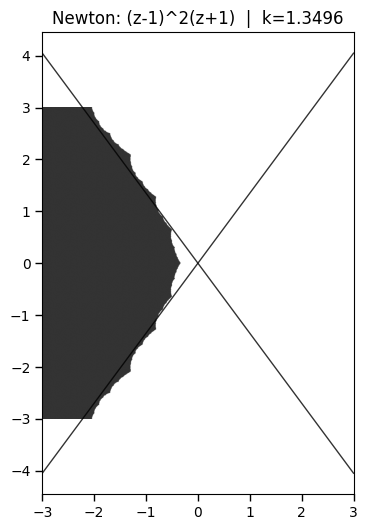

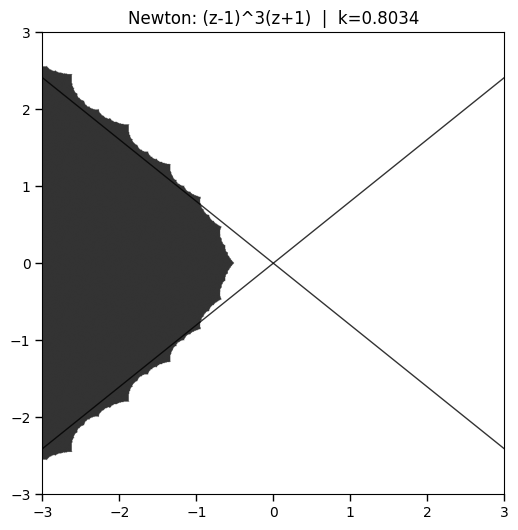

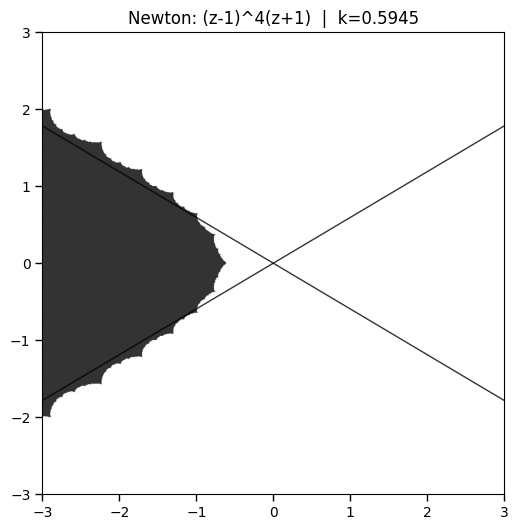

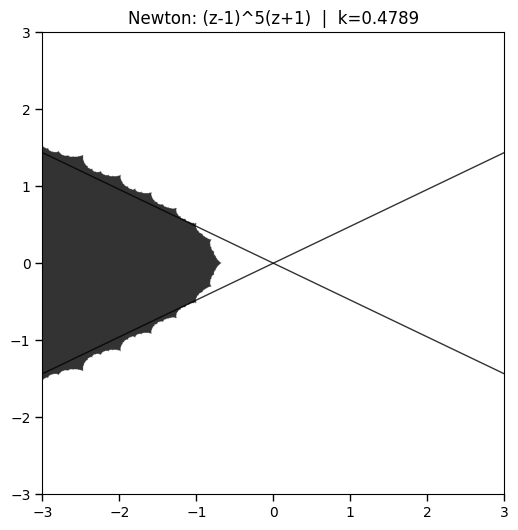

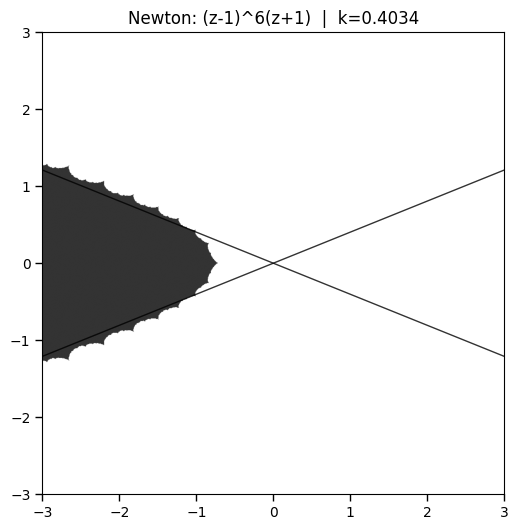

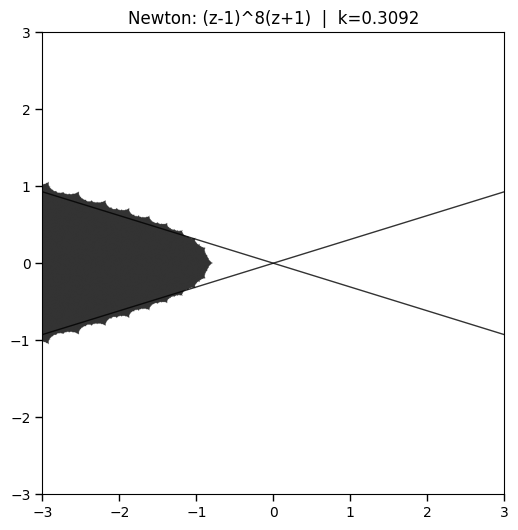

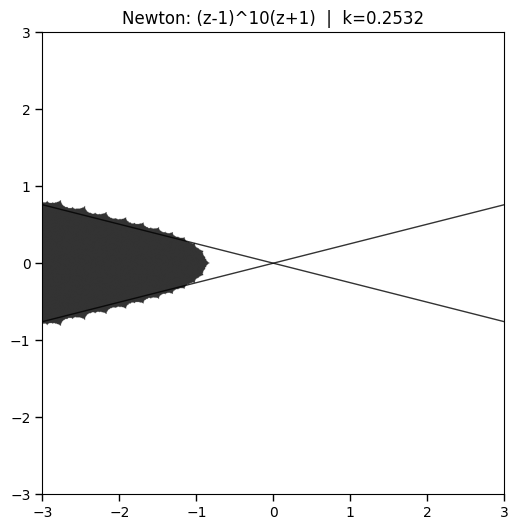

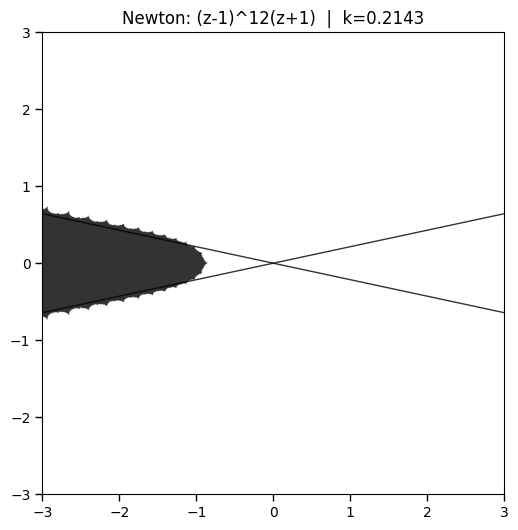

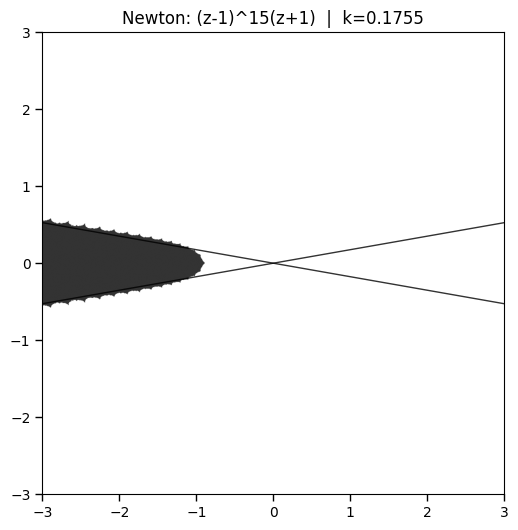

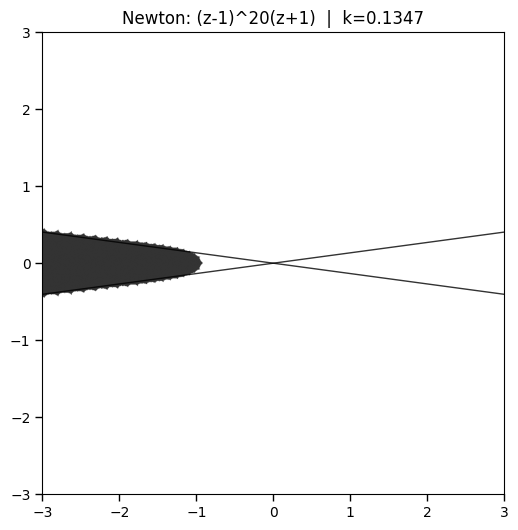

In [4]:
# Visualizacion opcional para un m concreto (cambia m_plot)
ms=[2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
for m_plot in ms:    
# m_plot = 10
    stats = estimate_k_for_m(
        m_plot,
        R=R,
        points=points,
        max_iter=max_iter,
        tol=tol,
        use_converged_only=use_converged_only,
        return_grid=True,
    )

    plot_basin_with_lines(
        stats["xs"],
        stats["ys"],
        stats["root_ids"],
        stats["k"],
        title=f"Newton: (z-1)^{m_plot}(z+1)  |  k={stats['k']:.4f}",
    )


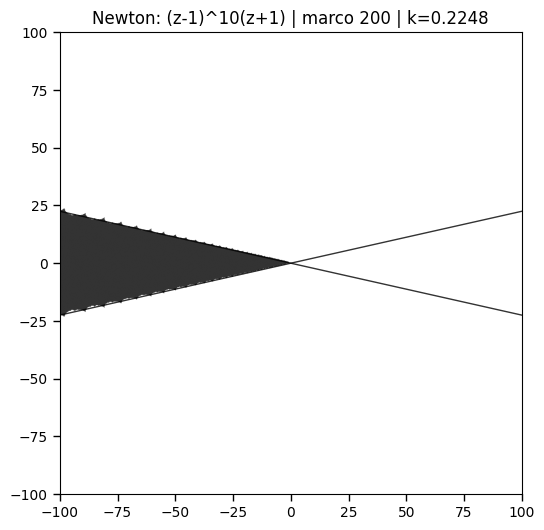

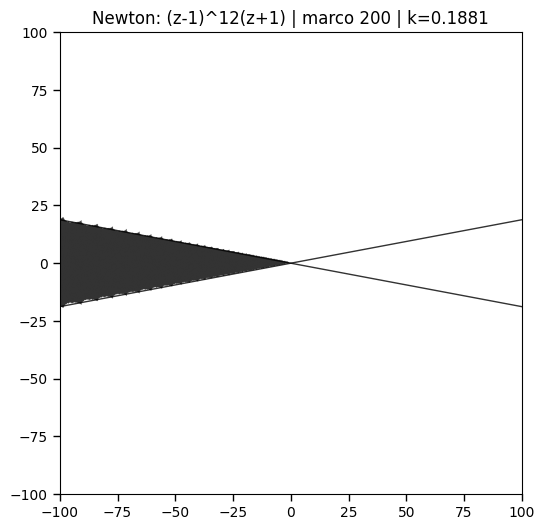

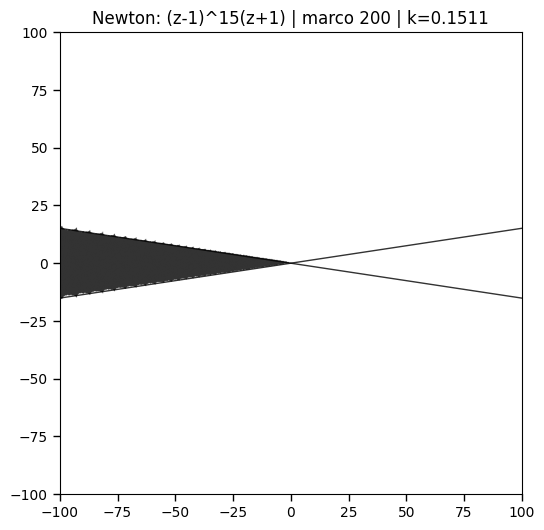

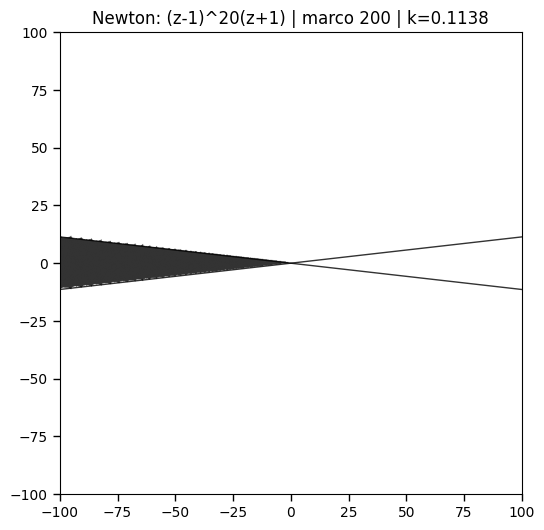

In [8]:
# Dibujo con marco grande (lado 200) para varios m
R_big = 100.0  # lado 200 -> [-100, 100]
points_big = 900
max_iter_big = 200
m_values_big = [10, 12, 15, 20]

for m_plot_big in m_values_big:
    stats_big = estimate_k_for_m(
        m_plot_big,
        R=R_big,
        points=points_big,
        max_iter=max_iter_big,
        tol=1e-6,
        use_converged_only=False,
        return_grid=True,
    )

    plot_basin_with_lines(
        stats_big["xs"],
        stats_big["ys"],
        stats_big["root_ids"],
        stats_big["k"],
        title=f"Newton: (z-1)^{m_plot_big}(z+1) | marco 200 | k={stats_big['k']:.4f}",
    )


## Comparacion por razon m/n

Comparamos dibujos y porcentaje de la raiz de multiplicidad 1 (z = -1)
para pares (m, n) con la misma razon m/n.


In [10]:
def newton_step_z_minus_1_power_n_z_plus_1(z, n):
    """Newton para p(z) = (z-1)^n (z+1)."""
    z = np.asarray(z, dtype=np.complex128)
    pz = (z - 1) ** n * (z + 1)
    dp = (z - 1) ** (n - 1) * ((n + 1) * z + (n - 1))
    update = np.zeros_like(z)
    np.divide(pz, dp, out=update, where=dp != 0)
    return z - update


def compute_root_ids_mn(m, n, x_range, y_range, points, max_iter, tol=1e-6):
    xs = np.linspace(x_range[0], x_range[1], points)
    ys = np.linspace(y_range[1], y_range[0], points)
    grid = xs[None, :] + 1j * ys[:, None]
    current = grid.copy()
    root_ids = np.zeros(grid.shape, dtype=int)

    for _ in range(max_iter):
        active = root_ids == 0
        if not np.any(active):
            break
        updated = newton_step_z_minus_1_power_n_z_plus_1(current[active], m)
        current[active] = updated

        new_ids = np.zeros_like(updated, dtype=int)
        new_ids[np.abs(updated + 1) < tol] = 1  # z = -1 (multiplicidad 1)
        new_ids[np.abs(updated - 1) < tol] = 2

        if np.any(new_ids):
            stored = root_ids[active]
            mask = new_ids > 0
            stored[mask] = new_ids[mask]
            root_ids[active] = stored

    return xs, ys, root_ids


def estimate_k_for_mn(m, n, R=3.0, points=900, max_iter=120, tol=1e-6):
    xs, ys, root_ids = compute_root_ids_mn(
        m,
        n,
        x_range=(-R, R),
        y_range=(-R, R),
        points=points,
        max_iter=max_iter,
        tol=tol,
    )
    X, Y = np.meshgrid(xs, ys)
    disk = (X ** 2 + Y ** 2) <= (R ** 2)
    mask_minus1 = (root_ids == 1) & disk

    count_minus1 = int(mask_minus1.sum())
    count_disk = int(disk.sum())

    g = count_minus1 / max(count_disk, 1)
    k = np.tan(np.pi * g)
    theta_deg = np.degrees(np.arctan(k))

    return {
        "m": m,
        "n": n,
        "g": g,
        "k": k,
        "theta_deg": theta_deg,
        "xs": xs,
        "ys": ys,
        "root_ids": root_ids,
    }


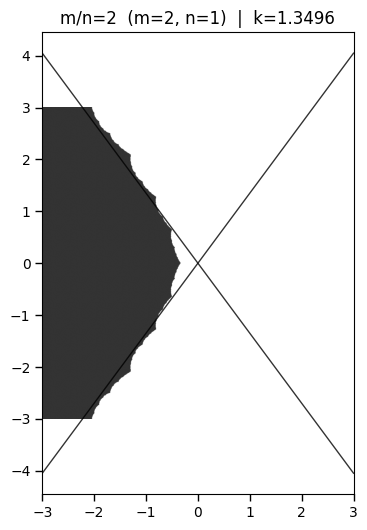

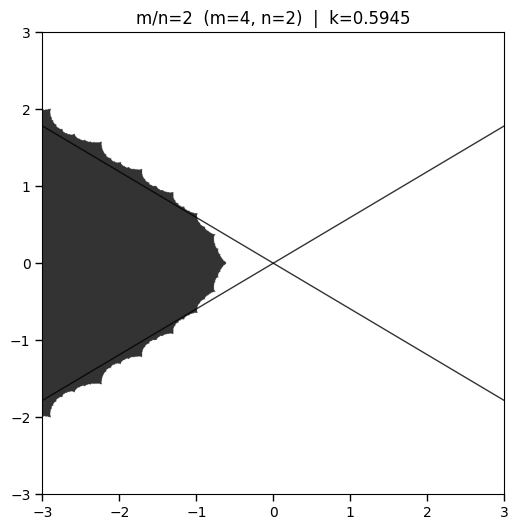

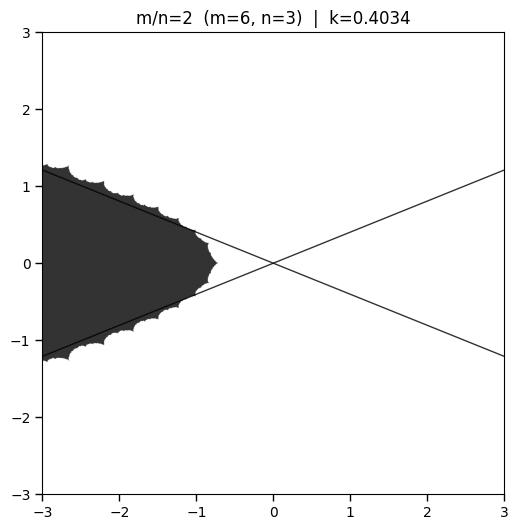

m  n   g (z=-1)    k        theta_deg
------------------------------------------
 2  1  0.297016   1.349591   53.4628
 4  2  0.170719   0.594452   30.7294
 6  3  0.122055   0.403416   21.9699


In [11]:
# Comparacion para m/n = 2
pairs_ratio_2 = [(2, 1), (4, 2), (6, 3)]
R_cmp = 3.0
points_cmp = 900
max_iter_cmp = 120

results_ratio_2 = []
for m, n in pairs_ratio_2:
    stats = estimate_k_for_mn(
        m,
        n,
        R=R_cmp,
        points=points_cmp,
        max_iter=max_iter_cmp,
    )
    results_ratio_2.append(stats)
    plot_basin_with_lines(
        stats["xs"],
        stats["ys"],
        stats["root_ids"],
        stats["k"],
        title=f"m/n=2  (m={m}, n={n})  |  k={stats['k']:.4f}",
    )

print("m  n   g (z=-1)    k        theta_deg")
print("-" * 42)
for r in results_ratio_2:
    print(f"{r['m']:>2} {r['n']:>2}  {r['g']:.6f}   {r['k']:.6f}   {r['theta_deg']:.4f}")


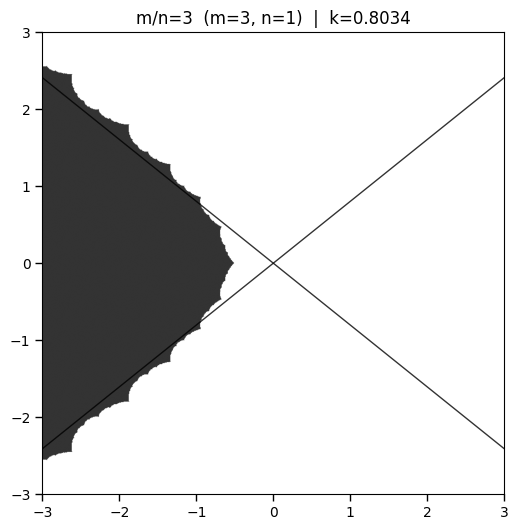

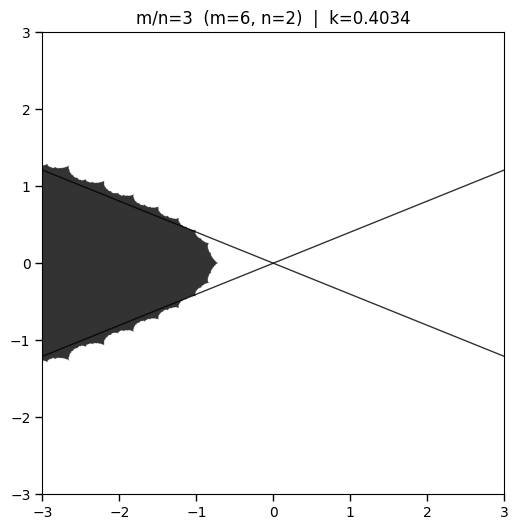

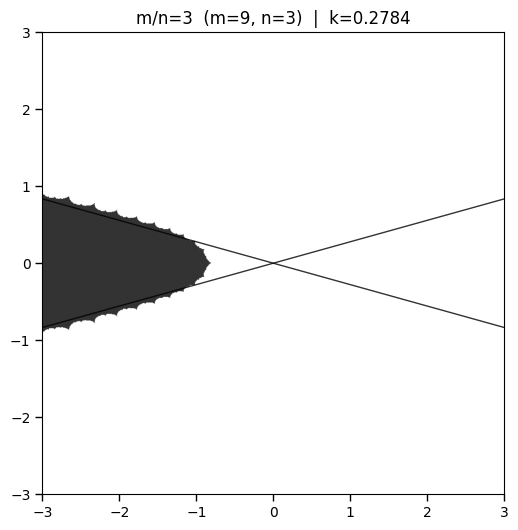

m  n   g (z=-1)    k        theta_deg
------------------------------------------
 3  1  0.215441   0.803428   38.7794
 6  2  0.122055   0.403416   21.9699
 9  3  0.086437   0.278428   15.5587


In [12]:
# Comparacion para m/n = 3
pairs_ratio_3 = [(3, 1), (6, 2), (9, 3)]
R_cmp = 3.0
points_cmp = 900
max_iter_cmp = 120

results_ratio_3 = []
for m, n in pairs_ratio_3:
    stats = estimate_k_for_mn(
        m,
        n,
        R=R_cmp,
        points=points_cmp,
        max_iter=max_iter_cmp,
    )
    results_ratio_3.append(stats)
    plot_basin_with_lines(
        stats["xs"],
        stats["ys"],
        stats["root_ids"],
        stats["k"],
        title=f"m/n=3  (m={m}, n={n})  |  k={stats['k']:.4f}",
    )

print("m  n   g (z=-1)    k        theta_deg")
print("-" * 42)
for r in results_ratio_3:
    print(f"{r['m']:>2} {r['n']:>2}  {r['g']:.6f}   {r['k']:.6f}   {r['theta_deg']:.4f}")
